# Notebook - Análise do Quicksort
## 1. Importação das bibliotecas
Bibliotecas numpy e pandas importadas para trabalhar com dados, matplot para trabalhar com gráficos

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## 2. Carregar os Dados
Carregar quick.csv para analisar dados do quicksort

In [2]:
quick = pd.read_csv("../results/quick.csv")
quick.head()

,vector_type,algorithm,size,time_ms,stress,carga,ram_kb_max,ram_kb_media,energy_j,comparisons,swaps
0,endnoise,QuickSort,10000000,368.159,none,0.0,43132,42938,8.07957,530500174,161104803
1,ordered,QuickSort,10000000,265.723,none,0.0,43076,42881,5.92619,426445618,116046024
2,random,QuickSort,10000000,841.404,none,0.0,43092,42899,16.10130,585074947,149196793
3,random_swaps,QuickSort,10000000,490.701,none,0.0,43128,42934,10.92110,688909350,216882152
4,repeated_1_5,QuickSort,10000000,2505.790,none,0.0,43128,42935,55.84020,258330577,121244670


## 3. Estatísticas Descritivas
Por combinação de mesmo vetor e estresse, obter média dos dados e standard deviation do tempo.

In [3]:
summary = (
    quick
    .groupby(["vector_type","stress","carga"])
    .agg(
        tempo_medio=("time_ms","mean"),
        desvio=("time_ms","std"),
        memoria_pico=("ram_kb_max","mean"),
        memoria_media=("ram_kb_media","mean"),
        energia=("energy_j","mean"),
        comparacoes=("comparisons","mean"),
        swaps=("swaps","mean")
    )
)

summary

tempo_medio      desvio  memoria_pico  \
vector_type  stress carga                                          
endnoise     both   0.5       489.8368   32.163782    16819936.0   
                    1.0       945.9810  156.919595    31070218.4   
             cpu    0.5       471.2384   18.913792       43232.0   
                    1.0       682.7848   78.343073       43288.8   
             none   0.0       377.1734   10.781321       43108.0   
             ram    0.5       382.4544   17.550773    16819967.2   
                    1.0       566.8700   20.094917    31058660.0   
ordered      both   0.5       331.1196    0.312909    16820143.2   
                    1.0       734.5892  103.643060    31085648.0   
             cpu    0.5       343.5856   20.293469       43249.6   
                    1.0       443.4666   95.874909       43281.6   
             none   0.0       272.4596    6.421837       43092.8   
             ram    0.5       284.5048   13.671618    16819936.8   
                    1.0       412.6472   34.682707    31077218.4   
random       both   0.5      1013.3898   59.248916    16820054.4   
                    1.0      1782.2460  431.069620    31099439.2   
             cpu    0.5      1006.2214   69.467190       43234.4   
                    1.0      1299.5700  200.468193       43280.0   
             none   0.0       813.3642   25.778147       43117.6   
             ram    0.5       845.2316   48.968936    16819988.8   
                    1.0      1085.1680  104.103448    31107024.0   
random_swaps both   0.5       652.0784   44.091095    16820013.6   
                    1.0      1275.4860  103.100912    31090181.6   
             cpu    0.5       654.2342   45.522417       43237.6   
                    1.0       908.0314  187.263662       43282.4   
             none   0.0       495.8350   11.469023       43102.4   
             ram    0.5       498.5320    4.838919    16819980.8   
                    1.0       658.7028   60.104013    31105739.2   
repeated     both   0.5      3451.3780  127.840182    16820006.4   
                    1.0      5814.8880  532.663894    31113957.6   
             cpu    0.5      3427.7600  109.995265       43252.8   
                    1.0      4046.1200  237.249088       43288.0   
             none   0.0      2886.9280  339.678021       43104.8   
             ram    0.5      2952.5180  464.849053    16819869.6   
                    1.0      3457.2100  265.389762    31112300.8   
repeated_1_5 both   0.5      3351.0500  180.542387    16820025.6   
                    1.0      5639.5640  905.459795    31069348.8   
             cpu    0.5      3132.4280   36.853791       43238.4   
                    1.0      4113.3180  180.505043       43268.0   
             none   0.0      2549.8000   63.888165       43129.6   
             ram    0.5      2569.0000   80.964603    16819864.0   
                    1.0      3518.8280  215.541502    31037322.4   
reversed     both   0.5       418.9356   22.514614    16820008.0   
                    1.0       890.5064   70.893218    31073622.4   
             cpu    0.5       397.9370   16.982783       43227.2   
                    1.0       553.1822  121.224302       43265.6   
             none   0.0       296.9664    0.834921       43116.8   
             ram    0.5       305.1222   13.607733    16819936.0   
                    1.0       487.7364   45.937457    31008938.4   
zigzag       both   0.5       497.6034   22.384046    16820094.4   
                    1.0      1159.6968  141.107378    31069374.4   
             cpu    0.5       529.6296   27.104814       43241.6   
                    1.0       793.1074  133.133245       43276.0   
             none   0.0       399.1022   14.133502       43118.4   
             ram    0.5       408.2100   17.338552    16819928.0   
                    1.0       564.5936   54.300320    31016390.4   

                           memoria_media     energia  comparacoes        swaps  
v

### Análise dados estatícos:
O tempo de execução aumenta progressivamente conforme cresce o nível de estresse. Em todos os tipos de entrada, o menor tempo foi obtido sem estresse (none), seguido pelo estresse apenas de RAM, pelo estresse de CPU e, por fim, pelo estresse combinado (both) com carga 1,0.

Esse padrão é consistente em todos os vetores analisados. Por exemplo, no vetor random, o tempo cresce de aproximadamente 813 ms (sem estresse) para 1782 ms sob estresse combinado, representando um aumento superior a 100%. Em vetores mais regulares, como ordered, o aumento é menos agressivo, mas ainda significativo.

---
Assim como observado em outros algoritmos de ordenação, o vetor random apresentou os maiores tempos absolutos de execução na maioria dos cenários. Entretanto, o impacto do estresse combinado foi particularmente forte, indicando que o Quicksort é altamente sensível à contenção de CPU e memória quando executado em condições adversas.

Diferentemente do MergeSort, o Quicksort apresenta forte dependência da distribuição dos elementos de entrada. Essa característica é evidente nos resultados: os vetores repeated e repeated_1_5 apresentaram os maiores tempos de execução do conjunto, chegando a aproximadamente 5.8 s e 5.6 s, respectivamente, sob estresse máximo.

Esse comportamento sugere degradação do particionamento, possivelmente causada por uma estratégia de pivô pouco robusta, levando a execuções mais próximas do pior caso (O(n²)) em entradas com alta repetição de valores.

---

O desvio padrão aumenta conforme cresce a intensidade do estresse.

Nas execuções sem estresse, a maioria dos vetores apresentou desvios relativamente baixos (entre ~6 ms e ~25 ms). No entanto, sob estresse combinado (both), os desvios aumentam significativamente, chegando a valores superiores a 400 ms no vetor random e ultrapassando 500 ms no vetor repeated.

Esse comportamento evidencia que a competição por recursos do sistema aumenta não apenas o tempo médio de execução, mas também sua variabilidade, tornando o desempenho do Quicksort menos previsível sob carga.

---

O número de comparações e swaps permaneceu constante para um mesmo tipo de entrada em todos os níveis de estresse, demonstrando que os mecanismos de geração de carga não alteram o comportamento lógico do algoritmo.

Observa-se, no entanto, que o número de operações varia significativamente entre os tipos de vetor. O vetor random exigiu o maior número de comparações (≈585 milhões), enquanto entradas como repeated apresentaram valores menores (≈215 milhões), embora com maior tempo de execução.

Isso indica que o desempenho do Quicksort não depende apenas da quantidade de comparações, mas também da eficiência do particionamento e da distribuição dos elementos, que impactam diretamente o custo real por operação.

## 4. Gráfico de Tempo médio por tipo de vetor

<Figure size 800x500 with 0 Axes>

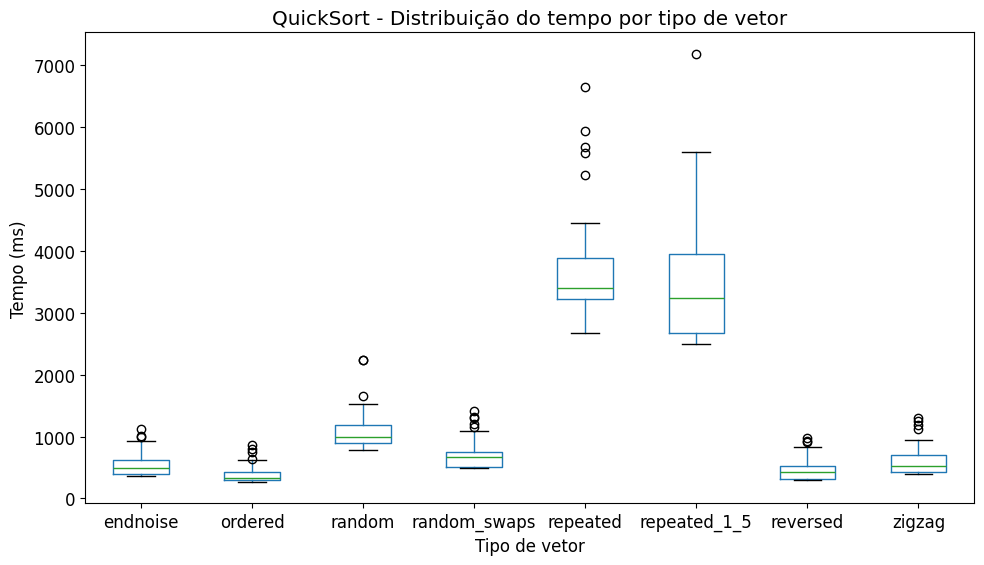

In [4]:
plt.figure(figsize=(8,5))
quick.boxplot(column="time_ms", by="vector_type", grid=False)

plt.title("QuickSort - Distribuição do tempo por tipo de vetor")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")

plt.tight_layout()
plt.show()

### Análise do gráfico:
É possível ver fortemente a degeneração do quicksort, apesar do random conceitualmente seja o mais dificil de ordenar; Vemos que o algortimo na verdade tem problemas muito maiores com os 2 vetores repetidos, degenerando para a casa de 3500ms.

## 5. Gráfico de tempo médio por estresse

<Figure size 1000x500 with 0 Axes>

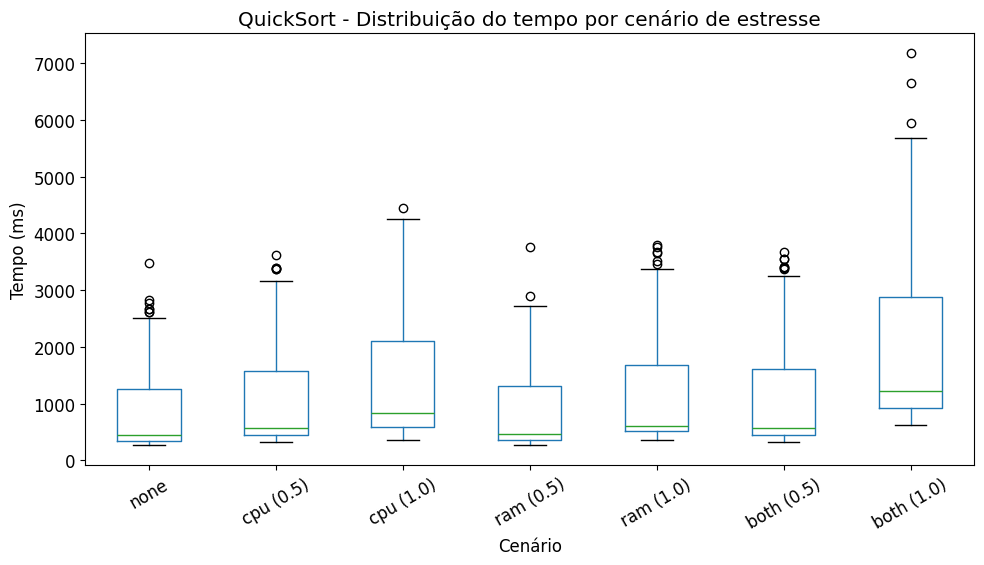

In [5]:
quick["cenario"] = quick.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

quick["cenario"] = pd.Categorical(
    quick["cenario"],
    categories=ordem,
    ordered=True
)

plt.figure(figsize=(10,5))

quick.boxplot(
    column="time_ms",
    by="cenario",
    grid=False
)

plt.title("QuickSort - Distribuição do tempo por cenário de estresse")
plt.suptitle("")
plt.ylabel("Tempo (ms)")
plt.xlabel("Cenário")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

### Análise do gráfico:
Os dados de boxplot aparenam estar poluídos  pelos casos degenerados. De qualquer jeito, é possível ver que none e RAM(0.5), apresentam menor tempos e both(1.0) é bem maior que o resto

## 6. Gráfico Estresse x Vetor

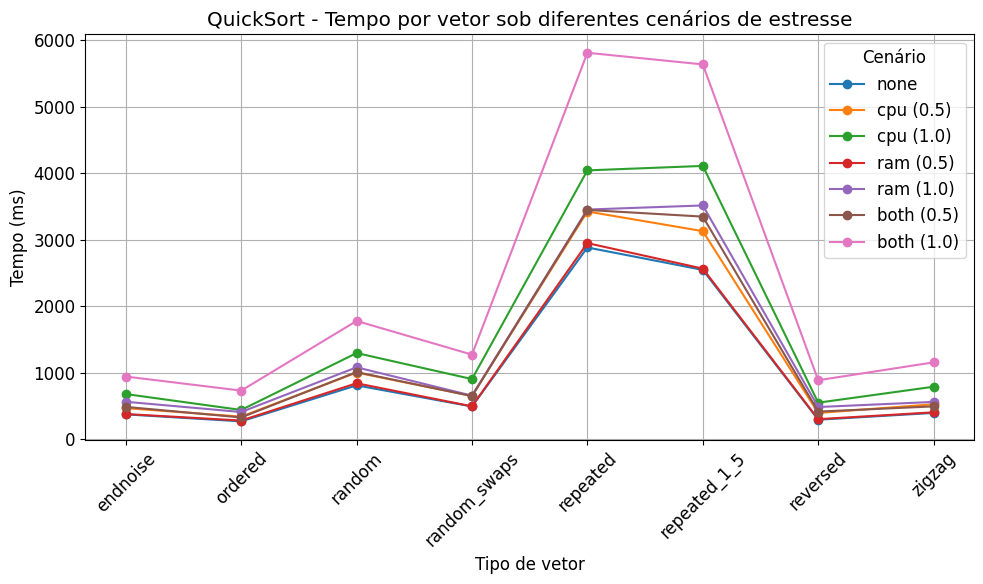

In [6]:
quick["cenario"] = quick.apply(
    lambda x: "none"
    if x["stress"] == "none"
    else f'{x["stress"]} ({x["carga"]})',
    axis=1
)

pivot = (
    quick
    .pivot_table(
        index="vector_type",
        columns="cenario",
        values="time_ms",
        aggfunc="mean"
    )
)

ordem = [
    "none",
    "cpu (0.5)",
    "cpu (1.0)",
    "ram (0.5)",
    "ram (1.0)",
    "both (0.5)",
    "both (1.0)"
]

pivot = pivot[ordem]

pivot.plot(marker="o", figsize=(10,6))

plt.ylabel("Tempo (ms)")
plt.xlabel("Tipo de vetor")
plt.title("QuickSort - Tempo por vetor sob diferentes cenários de estresse")

plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title="Cenário")

plt.tight_layout()
plt.show()

### Análise do gráfico:
Aqui é possível ver muito mais a atuação do quicksort, ele é o mais rápido em todos cenários que não degenera (repeated). Nos cenários que degenera é bem mais lento normalmente e mais ainda quando sob estresse. Segue tendência de None->Ram(0,5)->CPU(0,5)->Both(0,5)->Ram(1,0)->CPU(1,0)->Both(1,0)

## 7. Heatmap

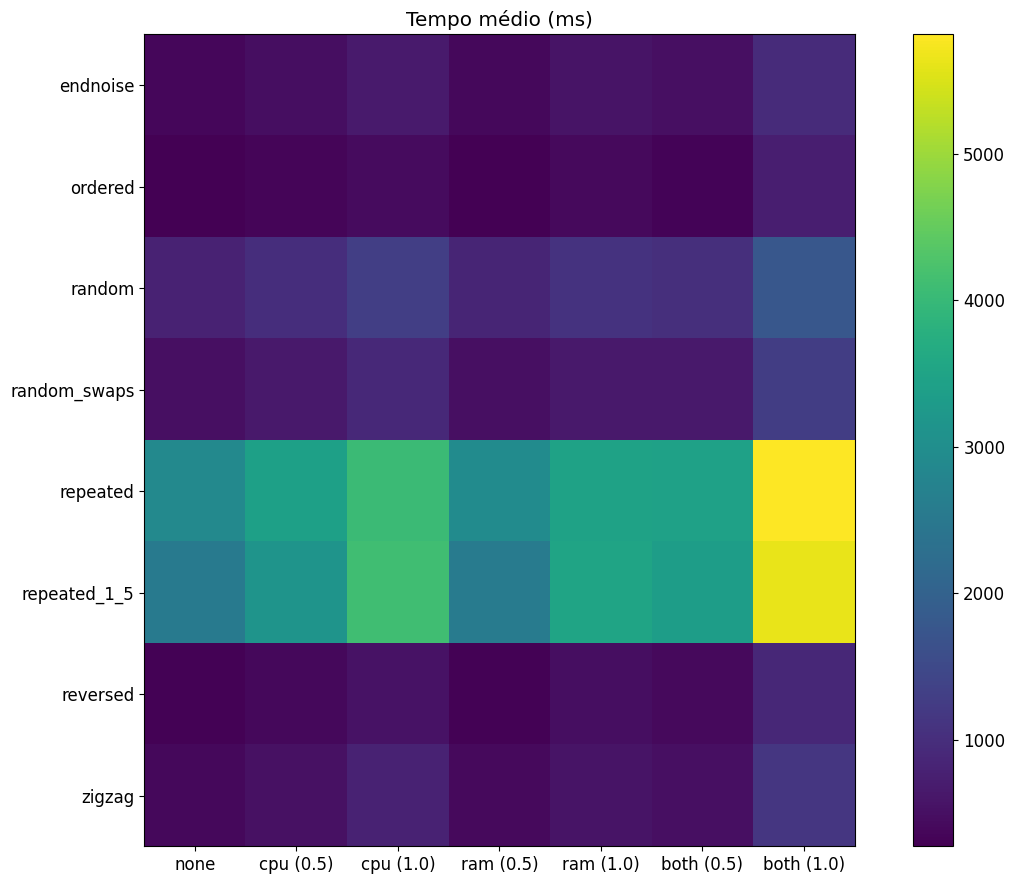

In [8]:
fig, ax = plt.subplots(figsize=(12,9))

im = ax.imshow(pivot.values)

ax.set_xticks(np.arange(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)

ax.set_yticks(np.arange(len(pivot.index)))
ax.set_yticklabels(pivot.index)

plt.title("Tempo médio (ms)")

plt.colorbar(im)

plt.tight_layout()
plt.show()

## 8. Memória

<Figure size 800x500 with 0 Axes>

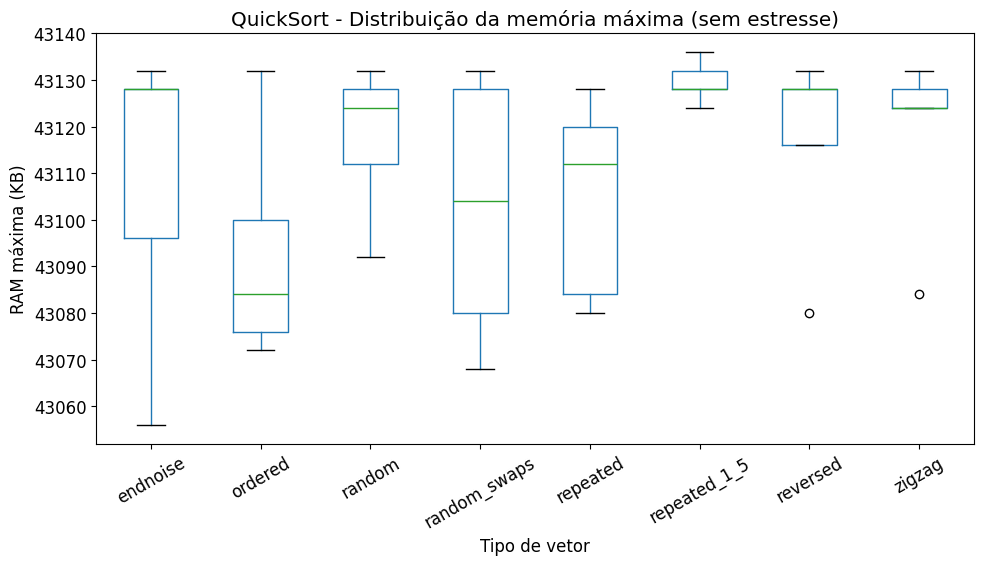

In [10]:
quick_none = quick[quick["stress"] == "none"]

plt.figure(figsize=(8,5))

quick_none.boxplot(
    column="ram_kb_max",
    by="vector_type",
    grid=False
)

plt.title("QuickSort - Distribuição da memória máxima (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM máxima (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso máximo bem consistente na casa de 43MB

<Figure size 800x500 with 0 Axes>

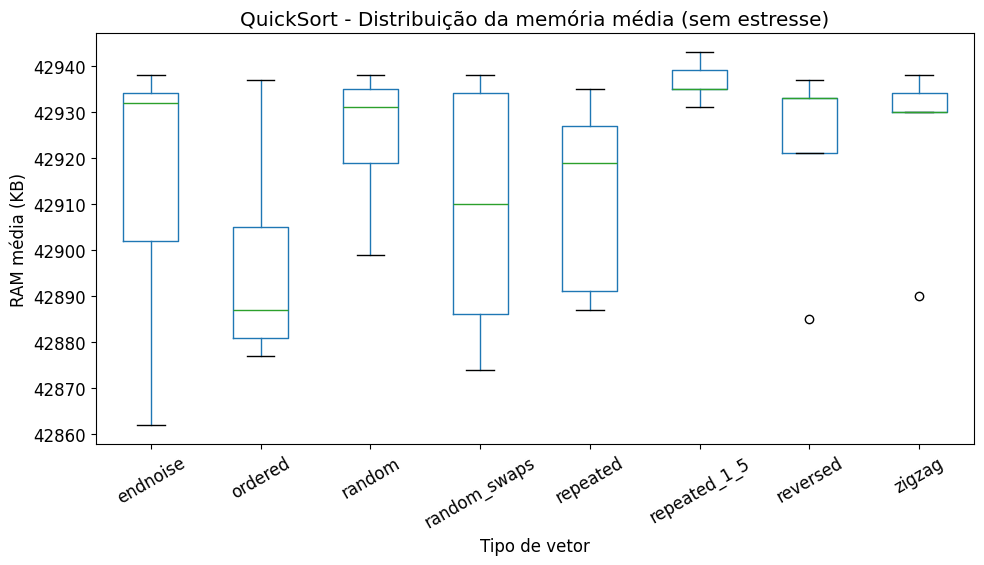

In [11]:
plt.figure(figsize=(8,5))

quick_none.boxplot(
    column="ram_kb_media",
    by="vector_type",
    grid=False
)

plt.title("QuickSort - Distribuição da memória média (sem estresse)")
plt.suptitle("")
plt.ylabel("RAM média (KB)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Uso de memória média bem parecido com máxima na casa dos 42,8~42,9MB

## 9. Energia

<Figure size 800x500 with 0 Axes>

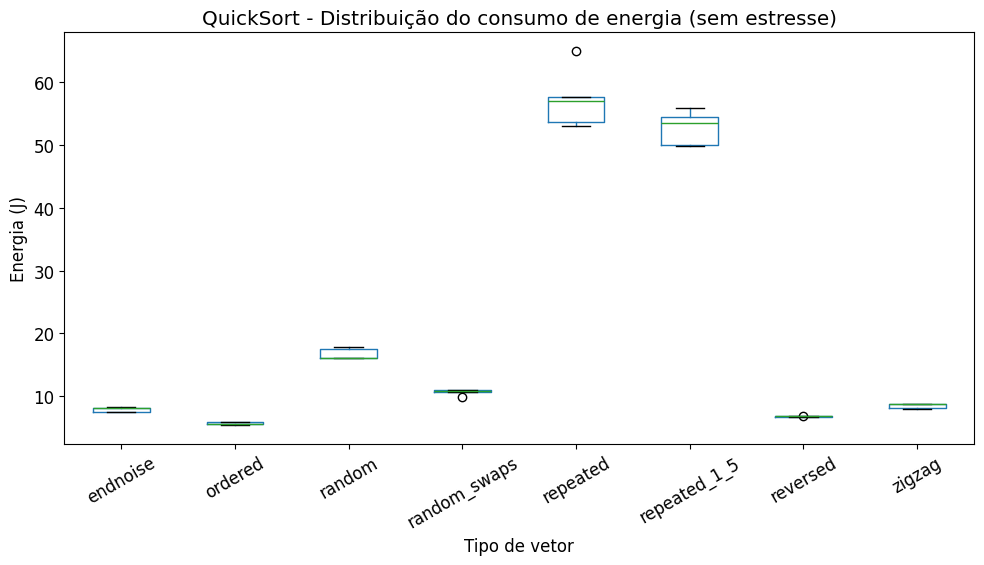

In [13]:
plt.figure(figsize=(8,5))

quick_none.boxplot(
    column="energy_j",
    by="vector_type",
    grid=False
)

plt.title("QuickSort - Distribuição do consumo de energia (sem estresse)")
plt.suptitle("")
plt.ylabel("Energia (J)")
plt.xlabel("Tipo de vetor")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Energia fortemente correlacionada com tempo

## 10 Correlações

In [14]:
quick_none[[
    "time_ms",
    "ram_kb_max",
    "ram_kb_media",
    "energy_j",
    "swaps",
    "comparisons"
]].corr()

,time_ms,ram_kb_max,ram_kb_media,energy_j,swaps,comparisons
time_ms,1.000000,0.122910,0.150241,0.995178,-0.391879,-0.787684
ram_kb_max,0.122910,1.000000,0.999177,0.142075,-0.077060,-0.099131
ram_kb_media,0.150241,0.999177,1.000000,0.169431,-0.074442,-0.109298
energy_j,0.995178,0.142075,0.169431,1.000000,-0.390685,-0.787665
swaps,-0.391879,-0.077060,-0.074442,-0.390685,1.000000,0.819749
comparisons,-0.787684,-0.099131,-0.109298,-0.787665,0.819749,1.000000


Tempo e energia fortemente correlacionados.

Memória max e memória média fortemente correlacionados. Poucas relações com o resto.

Comparações e swaps fortemente correlacionados, interessantemente fortementemente inversamente relacionados com tempo. Certamente influenciado pela degeneração;

## 11. Conclusões automáticas

In [15]:
print("Maior tempo médio:")

print(
    quick.groupby("vector_type")["time_ms"]
    .mean()
    .idxmax()
)

print("Menor tempo médio:")

print(
    quick.groupby("vector_type")["time_ms"]
    .mean()
    .idxmin()
)

print("Estresse mais custoso:")

print(
    quick.groupby("stress")["time_ms"]
    .mean()
    .idxmax()
)

Maior tempo médio:
repeated
Menor tempo médio:
ordered
Estresse mais custoso:
both
